회귀 계수 :
X1 : 1.7882
X2 : 2.9284
X3 : 1.5135
절편 : 0.1535
R-squared : 0.9566
RMSE :0.7174


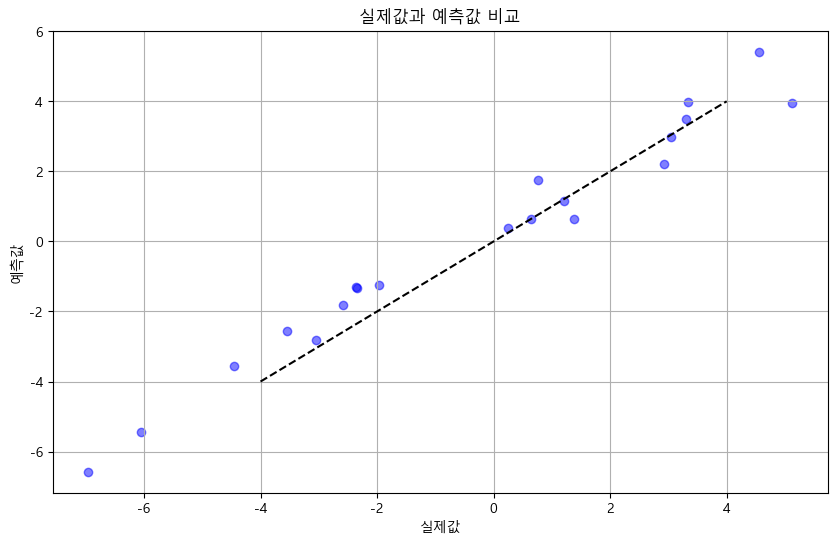

새로운 데이터 [[1.5 2.  0.5]]에 대한 예측값 : 9.4492


d:\python_sim\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수 표혁식으로 나올 때 지정 
pd.options.display.float_format = '{:.2f}'.format

# 샘플 데이터 생성
np.random.seed(42)
n_samples = 100 # 생성할 난수 크기

# 독립 변수 생성
X1 = np.random.normal(0, 1, n_samples) # np.random.normal(평균, 표준편차, 생성할 난수 개수)
X2 = np.random.normal(0, 1, n_samples)
X3 = np.random.normal(0, 1, n_samples)

# 종속 변수 생성 (Y = 2X1 + 3X2 + 1.5X3 + 오차)
Y = 2 * X1 + 3 * X2 + 1.5 * X3 + np.random.normal(0, 1, n_samples)

# 데이터 프레임 생성
data = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'Y': Y})

# 학습용과 테스트용 데이터 분리
X = data[['X1', 'X2', 'X3']]
y = data['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
model = LinearRegression()
model.fit(X_train,y_train)

# 예측
y_pred = model.predict(X_test)

# 결과 출력
print("회귀 계수 :")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature} : {coef:.4f}")
print(f"절편 : {model.intercept_:.4f}")
print(f"R-squared : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE :{np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# 실제값과 예측값 비교 시각화
plt.figure(figsize=(10,6))
plt.plot([-4,4],[-4,4],'k--') 
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('실제값과 예측값 비교')
plt.grid(True)
plt.show()

# 새로운 데이터로 예측 예시
new_data = np.array([[1.5, 2.0, 0.5]])
prediction = model.predict(new_data)
print(f"새로운 데이터 {new_data}에 대한 예측값 : {prediction[0]:.4f}")



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('dataset/LinearRegressionData.csv')

data.head()

,hour,score
0,0.50,10
1,1.20,8
2,1.80,14
3,2.40,26
4,2.60,22


In [3]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [ ]:
X, y

(array([[ 0.5],
        [ 1.2],
        [ 1.8],
        [ 2.4],
        [ 2.6],
        [ 3.2],
        [ 3.9],
        [ 4.4],
        [ 4.5],
        [ 5. ],
        [ 5.3],
        [ 5.8],
        [ 6. ],
        [ 6.1],
        [ 6.2],
        [ 6.9],
        [ 7.2],
        [ 8.4],
        [ 8.6],
        [10. ]]),
 array([ 10,   8,  14,  26,  22,  30,  42,  48,  38,  58,  60,  72,  62,
         68,  72,  58,  76,  86,  90, 100]))

In [4]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
y_pred1 = reg.predict(X)
y_pred1

array([-2.65279455, -0.5540646 ,  1.90673429,  2.09642493, -2.92050575,
       -0.57448853,  9.33875598,  2.78787485,  0.78106103,  6.73869126,
       -5.56836595,  0.89402651,  2.16360476,  4.89037335, -4.10754475,
        1.11464485, -3.04136526, -3.16263313,  1.07615912, -0.13458389,
        8.63603279, -5.86849572,  5.4132    , -9.12371869,  0.1128338 ,
        8.44002244, -4.84593306, -2.55053573, -1.80429152, -0.89762404,
       -6.71706674,  3.9972139 , -3.01376848, -1.43259547,  2.13724539,
        3.42078847, -4.94377241, -4.15348156, -0.93436308, -1.89759121,
        0.89709888,  4.09612815, -4.11316365,  1.4074808 , -3.6703578 ,
        0.58030821, -5.14080238, -2.89411404,  4.95537417, -1.62795565,
       -0.50511262,  1.81323142,  0.07997758,  3.46677121,  0.51479359,
       -1.07015649,  6.01832656, -0.15322463, -2.15936282,  4.99297636,
       -5.08794609,  1.98939972, -3.44657323, -6.08756293,  4.03614272,
        1.87683492,  4.88355276,  5.35080228, -0.65200544, -3.12

ValueError: x and y must be the same size

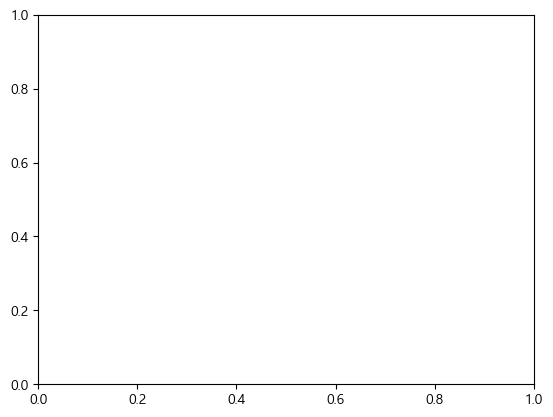

In [6]:
plt.scatter(X,y, color='blue')
plt.plot(X, y_pred1, color='red')
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()

# 다항회귀

R-squared : 0.9755
예측 성적 : 50.7


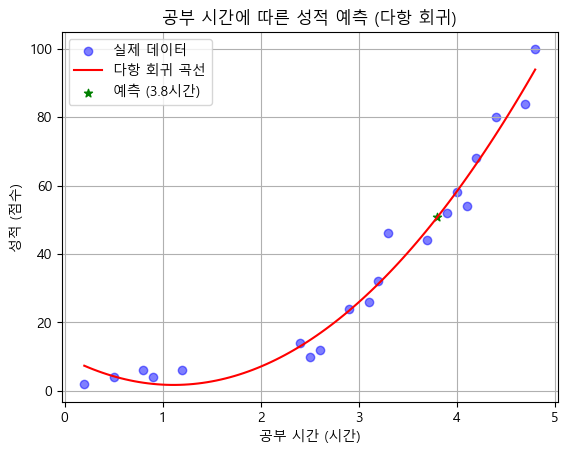

In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

# CSV 파일 읽기
data = pd.read_csv('dataset/PolynomialRegressionData.csv')

# 데이터 준비
X = data['hour'].values.reshape(-1,1) # 공부 시간 (독립 변수), 2차원 배열로
y = data['score'].values # 성적 (종속 변수)

# 다항 회귀 모델 생성 (2차 다항식)
degree = 2
polyreg = make_pipeline(PolynomialFeatures(degree), LinearRegression())
polyreg.fit(X, y)


# 모델 성능 평가
r_squared = polyreg.score(X, y)
print(f"R-squared : {r_squared:.4f}")

# 새로운 데이터로 예측 
new_hours = np.array([[3.8]])
pedicted_score = polyreg.predict(new_hours)
print(f'예측 성적 : {polyreg.predict(new_hours)[0]:.1f}')

# 시각화
# 데이터 포인트 산점도
plt.scatter(X, y, color='blue', alpha=0.5, label="실제 데이터")
 
# 다항 회귀 곡선 그리기
X_range = np.linspace(min(X), max(X), 100).reshape(-1,1) # 부드러운 곡선을 위해 범위 생ㅅ어
y_pred2 = polyreg.predict(X_range)
plt.plot(X_range, y_pred2, color='red', label="다항 회귀 곡선")

# 예측 데이터 포인터 표시
plt.scatter(new_hours, pedicted_score, color='green', marker='*', label="예측 (3.8시간)")

# 그래프 설정
plt.xlabel("공부 시간 (시간)")
plt.ylabel("성적 (점수)")
plt.title('공부 시간에 따른 성적 예측 (다항 회귀)')
plt.legend()
plt.grid(True)
plt.show()


# 경사하강법 예제

In [27]:
from sklearn.linear_model import SGDRegressor
sr = SGDRegressor(max_iter=200, eta0=1e-4, random_state=0, verbose=1) 
# max_iter : 모델 학습 횟수 , eta0 : 학습율 (1e-4 : 0.0001), versbose=1 학습 결과출력
sr.fit(X, y)

-- Epoch 1
Norm: 0.19, NNZs: 1, Bias: 0.046586, T: 20, Avg. loss: 1083.943386
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.31, NNZs: 1, Bias: 0.076798, T: 40, Avg. loss: 1062.311095
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.41, NNZs: 1, Bias: 0.103092, T: 60, Avg. loss: 1045.902321
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.50, NNZs: 1, Bias: 0.127370, T: 80, Avg. loss: 1031.334410
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.59, NNZs: 1, Bias: 0.149727, T: 100, Avg. loss: 1017.938104
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.68, NNZs: 1, Bias: 0.170946, T: 120, Avg. loss: 1005.519202
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.75, NNZs: 1, Bias: 0.191096, T: 140, Avg. loss: 993.806184
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.83, NNZs: 1, Bias: 0.210396, T: 160, Avg. loss: 982.699704
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 0.90, NNZs: 1, Bias: 0.228975, T: 180, Avg. loss: 972.097094
Total training t

d:\python_sim\venv\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,200
,tol,0.001
,shuffle,True
,verbose,1
,epsilon,0.1
,random_state,0


In [32]:
print(X_train.shape, y_train.shape)


(80, 3) (80,)


ValueError: x and y must be the same size

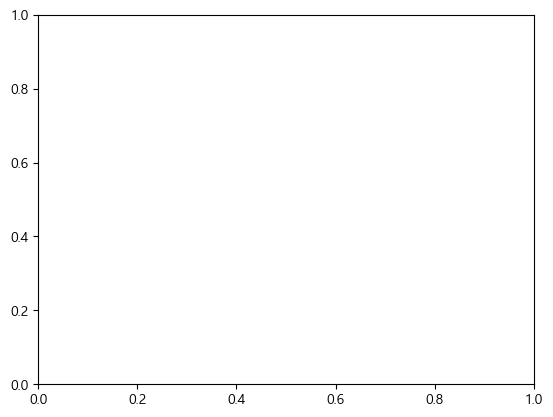

In [31]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, sr.predict(X_train), color='red')
plt.title('Score by hours')
plt.xlabel('hours')
plt.ylabel('score')
plt.show()